### Step 1: Load the Libraies and Data

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math
from tqdm import tqdm
import random
import os
import time
import seaborn as sns
from math import sqrt
from PyEMD import EMD
import ewtpy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [148]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_17412\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [149]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [150]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [151]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [152]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [153]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


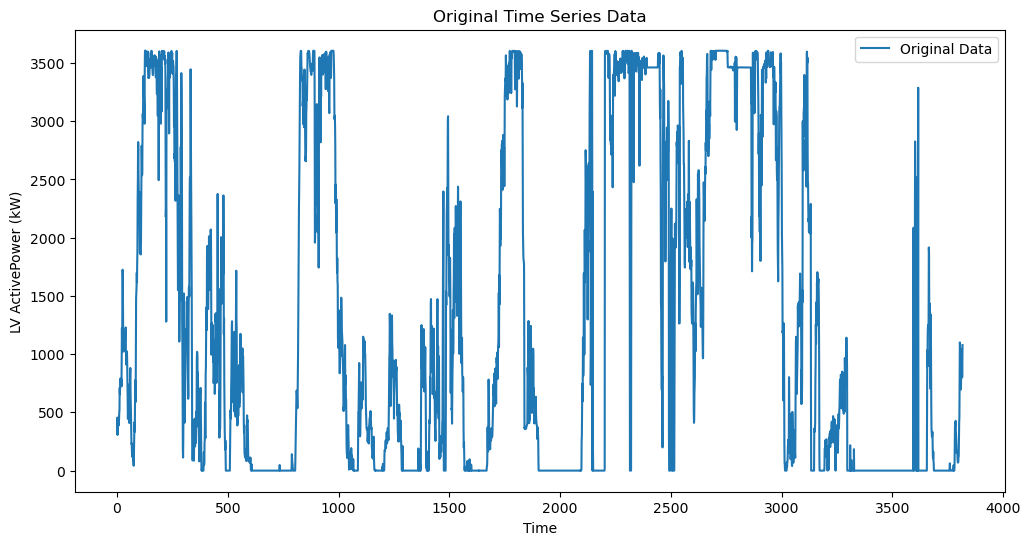

In [154]:
# Convert 'i' to a list and select data for the specified month
x = [1]
data1 = data.loc[data['Month'].isin(x)].reset_index(drop=True).dropna()
datas = data1['LV ActivePower (kW)']
dfs = datas.copy()
s = dfs.values.reshape(-1, 1)

# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(dfs.index, dfs.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()


In [155]:
s.shape

(3817, 1)

In [156]:
datas.shape

(3817,)

In [157]:
from PyEMD import EMD,EEMD,CEEMDAN
import ewtpy
# Perform CEEMDAN decomposition
emd = CEEMDAN(epsilon=0.05)
emd.noise_seed(12345)
s = s.flatten()  # Ensure s is a 1D array
IMFs = emd(s)

full_imf = pd.DataFrame(IMFs).T
ceemdan1 = full_imf

# Extract the first IMF
imf1 = ceemdan1.iloc[:, 0]
imf_dataps = np.array(imf1)
imf_datasetss = imf_dataps.reshape(-1, 1)
imf_new_datasets = pd.DataFrame(imf_datasetss)

# Perform EWT decomposition on the first IMF
ewt_coeffs, mfb, boundaries = ewtpy.EWT1D(imf1, N=3)
df_ewt = pd.DataFrame(ewt_coeffs)

# Remove the third column if it exists
if df_ewt.shape[1] > 2:
    df_ewt.drop(df_ewt.columns[2], axis=1, inplace=True)

# Sum the EWT components to get the denoised signal
denoised = df_ewt.sum(axis=1, skipna=True)

# Prepare the new CEEMDAN components by replacing the first IMF with the denoised signal
ceemdan_without_imf1 = ceemdan1.iloc[:, 1:].reset_index(drop=True)
denoised = denoised.reset_index(drop=True)
new_ceemdan = pd.concat([denoised, ceemdan_without_imf1], axis=1)
new_ceemdan.columns = range(new_ceemdan.shape[1])  # Reset column names

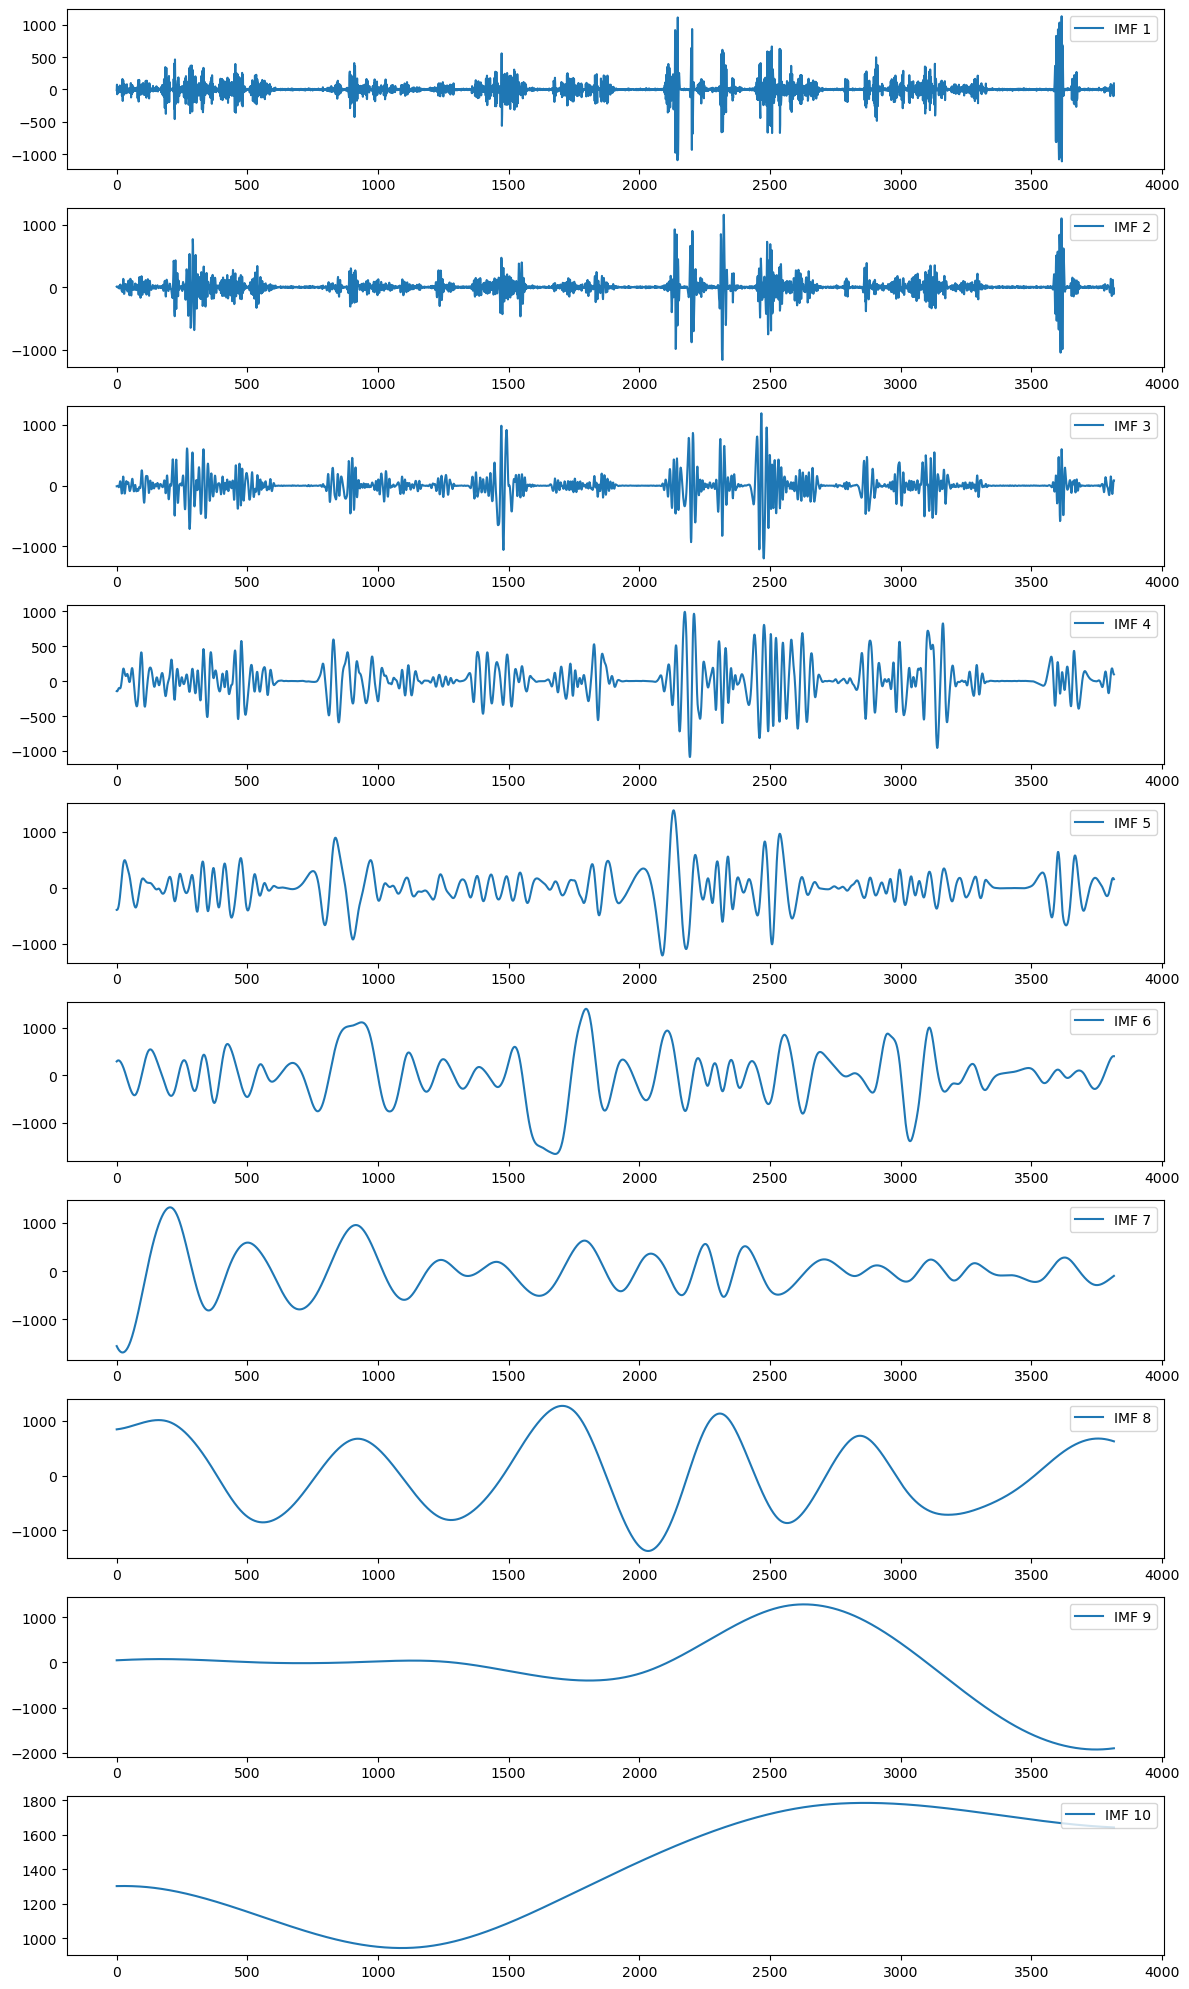

In [158]:
# Plot the CEEMDAN IMFs and the denoised signal
num_imfs = IMFs.shape[0]
plt.figure(figsize=(12, 2 * num_imfs))
for idx in range(num_imfs):
    plt.subplot(num_imfs, 1, idx + 1)
    plt.plot(ceemdan1.iloc[:, idx], label=f'IMF {idx + 1}')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

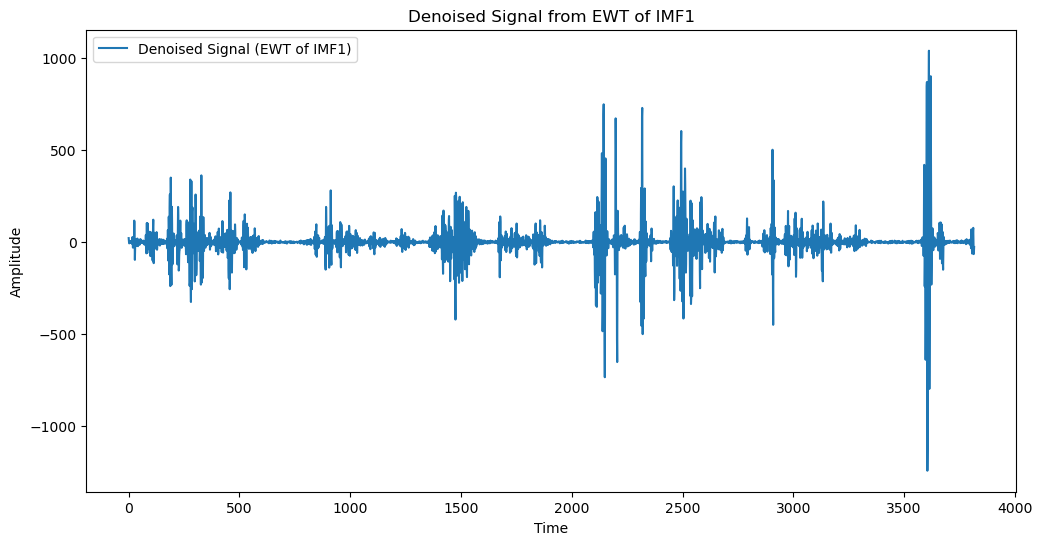

In [159]:
# Plot the denoised signal
plt.figure(figsize=(12, 6))
plt.plot(denoised, label='Denoised Signal (EWT of IMF1)')
plt.title('Denoised Signal from EWT of IMF1')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [160]:
# Function to create sequences of X and Y
def create_xy(data, input_length, output_length=1):
    x, y = [], []
    for i in range(len(data) - input_length - output_length + 1):
        x.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    return np.array(x), np.array(y)

## Step 3: Buidling the CEEMDAN-EWT with Transformer

In [161]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# Transformer Model
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=128, num_heads=2, num_layers=2, dim_feedforward=128, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()
        self.encoder = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, num_heads, dim_feedforward, dropout), num_layers
        )
        self.decoder = nn.Linear(d_model, 1)
    
    def forward(self, src):
        src = self.encoder(src) * math.sqrt(self.encoder.out_features) # (seq_len, batch_size, d_model)
        src = self.pos_encoder(src) # (seq_len, batch_size, d_model)
        output = self.transformer(src) # (seq_len, batch_size, d_model)
        return self.decoder(output[:, -1, :]) # (batch_size, 1)

# Custom Dataset Class
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [162]:
# Model parameters
input_length = 6
output_length = 1
batch_size = 64
epochs = 30
lr = 0.001
data_partition = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Process each column of new_ceemdan
pred_test, test_ori = [], []
pred_train, train_ori = [], []


In [163]:
for col in new_ceemdan:
    dataset_col = new_ceemdan[col].values.reshape(-1, 1)
    train_size = int(len(dataset_col) * 0.8)
    train, test = dataset_col[:train_size], dataset_col[train_size:]

    # Create input-output pairs
    trainX, trainY = create_xy(train, input_length, output_length)
    testX, testY = create_xy(test, input_length, output_length)

    # Scale data
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    trainX_scaled = scaler_x.fit_transform(trainX.reshape(-1, input_length)).reshape(-1, input_length, 1)
    trainY_scaled = scaler_y.fit_transform(trainY.reshape(-1, 1))
    testX_scaled = scaler_x.transform(testX.reshape(-1, input_length)).reshape(-1, input_length, 1)
    testY_scaled = scaler_y.transform(testY.reshape(-1, 1))

    # Datasets and Loaders
    train_dataset = TimeSeriesDataset(torch.tensor(trainX_scaled, dtype=torch.float32),
                                      torch.tensor(trainY_scaled, dtype=torch.float32))
    test_dataset = TimeSeriesDataset(torch.tensor(testX_scaled, dtype=torch.float32),
                                     torch.tensor(testY_scaled, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model
    model = TimeSeriesTransformer().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training
    for epoch in tqdm(range(epochs)):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Predictions for train and test
    model.eval()
    y_pred_train_list, y_train_list = [], []
    y_pred_test_list, y_test_list = [], []

    with torch.no_grad():
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X).cpu().numpy()
            y_pred_train_list.append(outputs)
            y_train_list.append(batch_y.cpu().numpy())

        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X).cpu().numpy()
            y_pred_test_list.append(outputs)
            y_test_list.append(batch_y.cpu().numpy())

    # Inverse transform predictions and actuals
    y_pred_train_inv = scaler_y.inverse_transform(np.concatenate(y_pred_train_list).reshape(-1, 1))
    y_train_inv = scaler_y.inverse_transform(np.concatenate(y_train_list).reshape(-1, 1))

    y_pred_test_inv = scaler_y.inverse_transform(np.concatenate(y_pred_test_list).reshape(-1, 1))
    y_test_inv = scaler_y.inverse_transform(np.concatenate(y_test_list).reshape(-1, 1))

    pred_train.append(y_pred_train_inv.flatten())
    pred_test.append(y_pred_test_inv.flatten())
    train_ori.append(y_train_inv.flatten())
    test_ori.append(y_test_inv.flatten())

c:\Users\aalma\anaconda3\Lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
  0%|          | 0/30 [00:00<?, ?it/s]c:\Users\aalma\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\aalma\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([39, 1])) that is different to the input size (torch.Size([39])). This will likely lead to incorrect result

In [164]:
# Combine IMF Predictions
result_pred_test = pd.DataFrame(pred_test).T
result_pred_train = pd.DataFrame(pred_train).T

# Sum predictions across IMFs
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)

In [166]:
# Prepare actual data
dataset = dfs.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Generate actual y values using create_xy
_, testY = create_xy(test, input_length, output_length=output_length)

# Reshape testY to 2D array for scaling
testY_reshaped = testY.reshape(-1, 1)

# Scale and inverse-transform actual values
sc_y_total = StandardScaler()
testY_scaled = sc_y_total.fit_transform(testY_reshaped)

y_test_inv = sc_y_total.inverse_transform(testY_scaled).flatten()

In [167]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]


# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = metrics.mean_absolute_error(y_test_series, a)
r2 = metrics.r2_score(y_test_series, a)


# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 1169.966
MAE: 1057.672
R2: -1.702


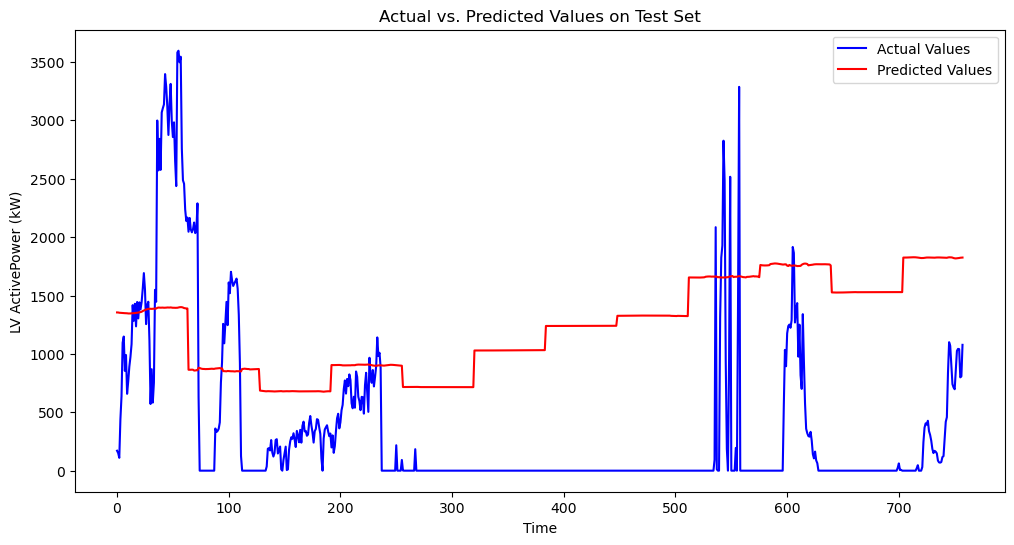

In [168]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()
